In [62]:
import numpy as np
import pandas as pd
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

In [73]:
def lat_long_to_spherical(lat,lon,p):
    # convert lat, long to xyz coordinates (using spherical transformation), center of earth is at 0,0,0
    # in degrees, 90º lat is north pole, -90º lat is south pole
    # azimuth ranges 0 - 180, adjust latitude to fit range
    theta = lon
    if theta < 180:
        theta = 180 + (180 - (-lon))
    phi = (lat - 90) * -1
    x = p*np.sin(np.deg2rad(phi))*np.cos(np.deg2rad(theta))
    y = p*np.sin(np.deg2rad(phi))*np.sin(np.deg2rad(theta))
    z = p*np.cos(np.deg2rad(phi))
    return x,y,z

In [77]:
def lat_long_to_spherical_vector(lat, lon, p):
    # take in lat/lon as vectors
    theta = lon
    theta = np.where(theta<180, 180 + (180 -(-lon)), theta)
    phi = (lat - 90) * -1
    x = p*np.sin(np.deg2rad(phi))*np.cos(np.deg2rad(theta))
    y = p*np.sin(np.deg2rad(phi))*np.sin(np.deg2rad(theta))
    z = p*np.cos(np.deg2rad(phi))
    return x,y,z

In [78]:
lat_long_to_spherical_vector(np.array([0,0]), np.array([90,-90]), np.array([100,100]))


(array([ 3.0616170e-14, -1.8369702e-14]),
 array([ 100., -100.]),
 array([6.123234e-15, 6.123234e-15]))

In [79]:
# tests, sanity checks because this was awful
x,y,z = lat_long_to_spherical(90, 0, 100)
assert np.all(np.isclose([x,y,z], [0,0,100]))

x,y,z = lat_long_to_spherical(-90, 0, 100)
assert np.all(np.isclose([x,y,z], [0,0,-100]))

x,y,z = lat_long_to_spherical(0, 0, 100)
assert np.all(np.isclose([x,y,z], [100,0,0]))

x,y,z = lat_long_to_spherical(0, 0, -100)
assert np.all(np.isclose([x,y,z], [-100,0,0]))

x,y,z = lat_long_to_spherical(0, 90, 100)
assert np.all(np.isclose([x,y,z], [0,100,0]))

x,y,z = lat_long_to_spherical(0, -90, 100)
assert np.all(np.isclose([x,y,z], [0,-100,0]))

x,y,z = lat_long_to_spherical_vector(np.array([90,-90]), np.array([0,0]), np.array([100,100]))
assert np.all(np.isclose([x,y,z], [[0,0],[0,0],[100,-100]]))

x,y,z = lat_long_to_spherical_vector(np.array([0,0]), np.array([90,-90]), np.array([100,100]))
assert np.all(np.isclose([x,y,z], [[0,0],[100,-100],[0,0]]))

In [80]:
# convert zip codes into latlon
# data from: https://gist.github.com/erichurst/7882666
zips = pd.read_csv("data/2013_us_zips.csv")
zips.head()

,ZIP,LAT,LNG
0,601,18.180555,-66.749961
1,602,18.361945,-67.175597
2,603,18.455183,-67.119887
3,606,18.158345,-66.932911
4,610,18.295366,-67.125135


In [81]:
# radius of earth: 3,963.1 mi (unit doesn't really matter)
xs,ys,zs = lat_long_to_spherical_vector(zips["LAT"],zips["LNG"], 3963.1)
zips["x_mi"] = xs
zips["y_mi"] = ys
zips["z_mi"] = zs
zips.head()
zips_m = zips[["ZIP","x_mi", "y_mi", "z_mi"]]

In [90]:
r = 50 # miles, canonically (unit is a bit arbitrary)
nbrs = NearestNeighbors(radius=r)
nbrs.fit(zips_m.drop(columns=["ZIP"]))
nndist, nnb = nbrs.radius_neighbors(zips_m.iloc[1000:1001,:].drop(columns=["ZIP"]), return_distance=True, sort_results=True)
zmini = zips.iloc[nnb[0]]
zmini["nndist"] = nndist[0]
zmini.head()

/var/folders/3n/8dzjfpg11pb2g2qd2j1vpwbc0000gn/T/ipykernel_75384/866049615.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  zmini["nndist"] = nndist[0]


,ZIP,LAT,LNG,x_mi,y_mi,z_mi,nndist
1000,3886,43.864038,-71.296068,916.286172,-2706.439279,2746.227902,0.000000
946,3817,43.887170,-71.229402,919.077762,-2704.321325,2747.381271,3.689033
997,3883,43.808537,-71.320336,915.991332,-2709.345939,2743.458779,4.025375
832,3259,43.875712,-71.395018,911.432242,-2707.487313,2746.810027,4.999788
994,3875,43.895078,-71.189275,920.849226,-2703.318020,2747.775463,5.740963


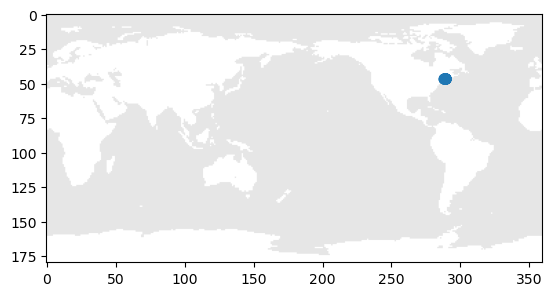

In [91]:
plt.figure()
topo = np.loadtxt("data/topography_180x360_grid.txt")
plt.imshow(topo>0, cmap="gray", alpha=0.1)
#lng to 360 *passes out*
newlng = np.where(zmini["LNG"]<180, 180 + (180 -(-zmini["LNG"])), zmini["LNG"])
newlat = (zmini["LAT"] - 90) * -1
plt.scatter(newlng, newlat)